### Подготовка данных

In [1]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly_champagne_sales.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Sales
42,1967-07,3663
50,1968-03,4154
91,1971-08,1659
55,1968-08,1723
28,1966-05,3937


In [2]:
len(time_series)

105

In [3]:
time_series.isnull().sum()

Month    0
Sales    0
dtype: int64

In [4]:
time_series.dtypes

Month    object
Sales     int64
dtype: object

In [5]:
time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series.set_index('Month', inplace=True)

In [6]:
time_series.dtypes

Sales    int64
dtype: object

In [7]:
time_series.sample(5)

,Sales
Month,
1966-12-01,9254
1964-05-01,2946
1968-06-01,4753
1967-07-01,3663
1964-02-01,2672


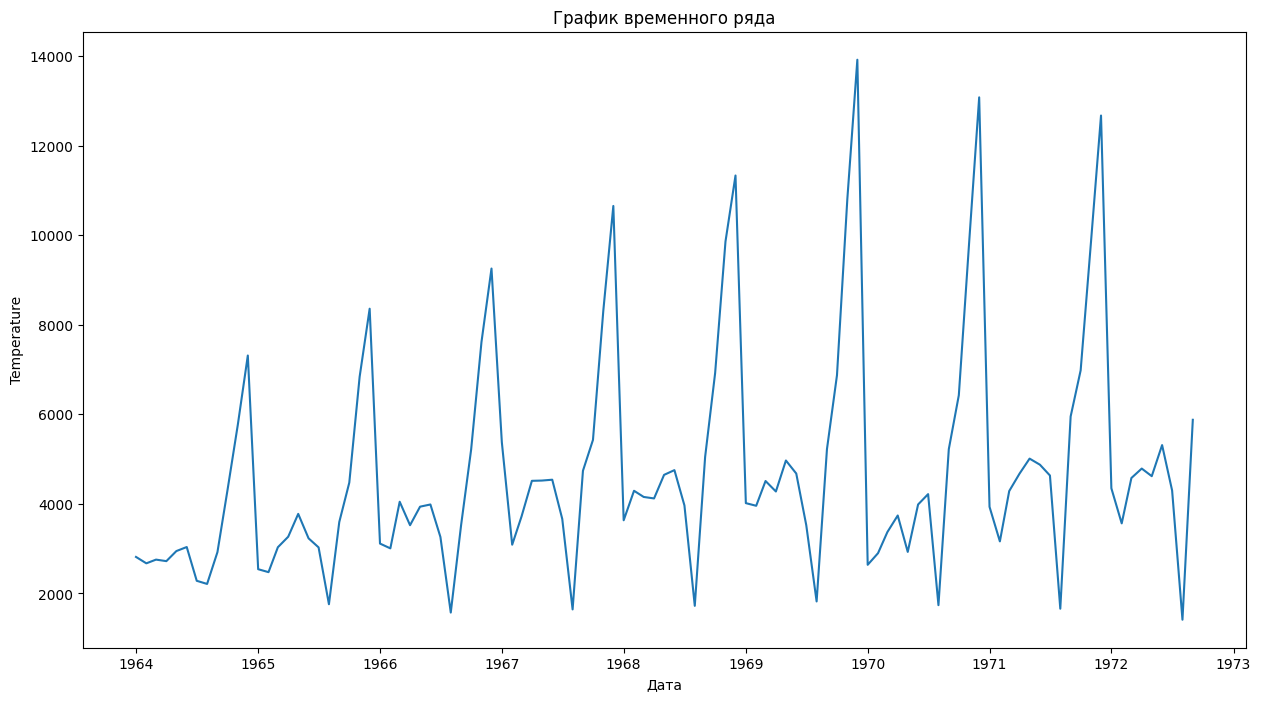

In [8]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Sales'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Temperature')
plt.show()

In [9]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [10]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [11]:
train.shape

(84, 1)

In [12]:
test.shape

(21, 1)

In [13]:
test.head()

,Sales
Month,
1971-01-01,3934
1971-02-01,3162
1971-03-01,4286
1971-04-01,4676
1971-05-01,5010


### Поиск параметров

In [14]:
def search_optimal_arima(time_series, seasonal_cycle):
    # Взял максимальный интервал, которое мое устройство осилило
    order_vals = diff_vals = ma_vals = range(0, 10)
    pdq_combinations = list(itertools.product(order_vals, diff_vals, ma_vals))

    smallest_aic = float("inf")
    optimal_order_param = None

    for order_param in pdq_combinations:
        try:
            arima_model = ARIMA(time_series,
                                order=order_param,
                                enforce_stationarity=False,
                                enforce_invertibility=False)

            model_results = arima_model.fit()
            if model_results.aic < smallest_aic:
                smallest_aic = model_results.aic
                optimal_order_param = order_param
        except:
            print("Aaa")
            continue

    return optimal_order_param, smallest_aic

seasonal_cycle_length = 12
#optimal_order_param, smallest_aic = search_optimal_arima(train, seasonal_cycle_length)
optimal_order_param, smallest_aic = (9, 5, 9), 1259.7005665206184
print('ARIMA{} - AIC:{}'.format(optimal_order_param, smallest_aic))

ARIMA(9, 5, 9) - AIC:1259.7005665206184


### Обучение модели

In [15]:
from statsmodels.tsa.arima.model import ARIMA

order = optimal_order_param

model = ARIMA(train, order=order)

In [16]:
fitted_model = model.fit()
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                   84
Model:                 ARIMA(9, 5, 9)   Log Likelihood                -734.401
Date:                Wed, 03 Jun 2026   AIC                           1506.801
Time:                        17:59:23   BIC                           1551.821
Sample:                    01-01-1964   HQIC                          1524.838
                         - 12-01-1970                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.9896      0.234     -8.487      0.000      -2.449      -1.530
ar.L2         -3.0307      0.391     -7.758      0.000      -3.796      -2.265
ar.L3         -3.9965      0.608     -6.572      0.000      -5.188      -2.805
ar.L4         -4.5700      0.709     -6.447      0.000      -5.959      -3.181
ar.L5         -4.5174      0.761     -5.932      0.000      -6.010      -3.025
ar.L6         -3.5746      0.705     -5.069      0.000      -4.957      -2.192
ar.L7         -2.6175      0.549     -4.768      0.000      -3.694      -1.541
ar.L8         -1.5497      0.337     -4.605      0.000      -2.209      -0.890
ar.L9         -0.5694      0.178     -3.205      0.001      -0.918      -0.221
ma.L1         -1.6616      1.710     -0.972      0.331      -5.012       1.689
ma.L2          1.1520      4.681      0.246      0.806      -8.023      10.328
ma.L3         -0.2473      5.723     -0.043      0.966     -11.464      10.969
ma.L4         -0.2376      4.986     -0.048      0.962     -10.011       9.536
ma.L5         -0.2142      4.970     -0.043      0.966      -9.955       9.527
ma.L6         -0.2799      5.574     -0.050      0.960     -11.205      10.645
ma.L7          1.2205      4.329      0.282      0.778      -7.263       9.704
ma.L8         -1.6135      1.515     -1.065      0.287      -4.583       1.356
ma.L9          0.9105      0.232      3.930      0.000       0.456       1.365
sigma2      3.379e+06   3.78e-05   8.93e+10      0.000    3.38e+06    3.38e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.55   Jarque-Bera (JB):                43.80
Prob(Q):                              0.21   Prob(JB):                         0.00
Heteroskedasticity (H):               2.38   Skew:                            -1.27
Prob(H) (two-sided):                  0.03   Kurtosis:                         5.61
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.39e+27. Standard errors may be unstable.
"""

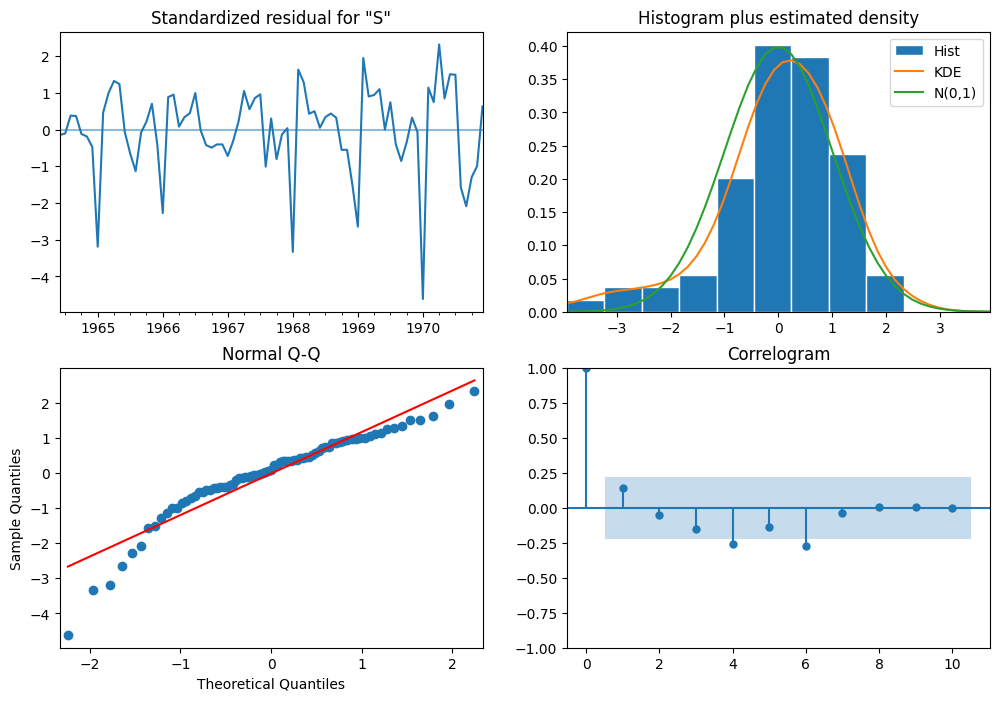

In [17]:
fitted_model.plot_diagnostics(figsize=(12, 8))
plt.show()

### Прогноз

In [18]:
pred = fitted_model.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
forecast_values = pred.predicted_mean

In [19]:
actual_values = test
forecast_mse = ((forecast_values - actual_values) ** 2).mean()

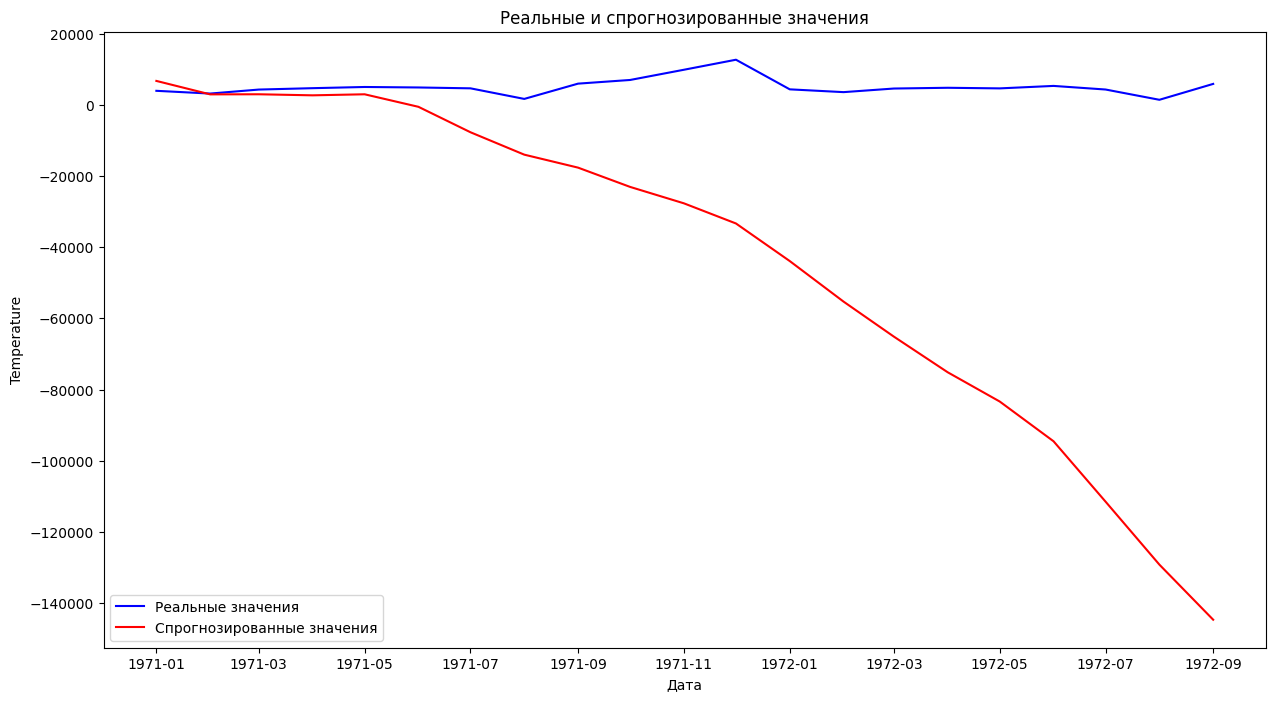

In [20]:
plt.figure(figsize=(15,8))

plt.plot(actual_values.index, actual_values, label='Реальные значения', color='blue')

plt.plot(forecast_values.index, forecast_values, label='Спрогнозированные значения', color='red')

plt.title('Реальные и cпрогнозированные значения')
plt.xlabel('Дата')
plt.ylabel('Temperature')
plt.legend()

plt.show()

### Реализации бутстрапа

In [21]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [22]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = error_magnitude
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [23]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast.values + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast.values + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [26]:
def evaluate(true_values, lower, upper, alpha=0.05):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)

    # Winkler score
    penalty_factor = 2 / alpha
    lower_penalty = penalty_factor * np.maximum(0, lower - true_vals)
    upper_penalty = penalty_factor * np.maximum(0, true_vals - upper)
    width_penalty = (upper - lower)
    winkler_scores = width_penalty + lower_penalty + upper_penalty
    avg_winkler = np.mean(winkler_scores)

    return coverage, avg_width, avg_winkler

forecast_steps = 20
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# ARIMA
try:
    prediction = fitted_model.get_forecast(forecast_steps)
    arima_forecast = prediction.predicted_mean
    arima_ci = prediction.conf_int(alpha=0.05)
    lower_arima = arima_ci.iloc[:, 0]
    upper_arima = arima_ci.iloc[:, 1]
    coverage_arima, width_arima, winkler_arima = evaluate(test_values, lower_arima, upper_arima)
    results['ARIMA'] = {'coverage': coverage_arima, 'width': width_arima, 'lower': lower_arima, 'upper': upper_arima, "winkler": winkler_arima}
    print("ARIMA - OK")
except Exception as e:
    print(f"Arima error: {e}")

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c, winkler_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c, 'winkler': winkler_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive, winkler_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive, "winkler": winkler_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch, winkler_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch, 'winkler': winkler_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve, winkler_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve, 'winkler': winkler_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block, winkler_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block, 'winkler': winkler_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width', 'winkler']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

ARIMA - OK
Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[ 2833.00570729 -9214.38554115  4865.44043437  1784.07201532
  1727.54446266  -919.39621645  -554.54842541  1932.31554228
  1750.70102292  -423.57725663  -591.53708151 -1404.81003857
 -9107.95255275  1233.48333725  2557.14180884  3267.59661467
  3035.89557494  -141.49018198 -1518.98307981 -2530.29371737
  -162.90962697   501.13820019  1552.21865519  -883.22519849
 -4880.50048209  1915.87495335  2044.41120594   191.60054514
   725.40985725   946.62186891  2083.58232132   -25.48838813
  -843.75987388  -979.21423623  -793.77606723  -788.6766329
 -1417.04470349  -589.65224575   472.08630088  2102.83190076
  1115.10824894  1713.4633153   1905.93073092 -1958.6937489
   610.14629325 -1551.87194149  -235.93878002    96.5853331
 -6445.62262069  3184.69476764  2518.53711484   852.34415535
   984.33912542   117.13887858   672.74944711   860.35183039
   64

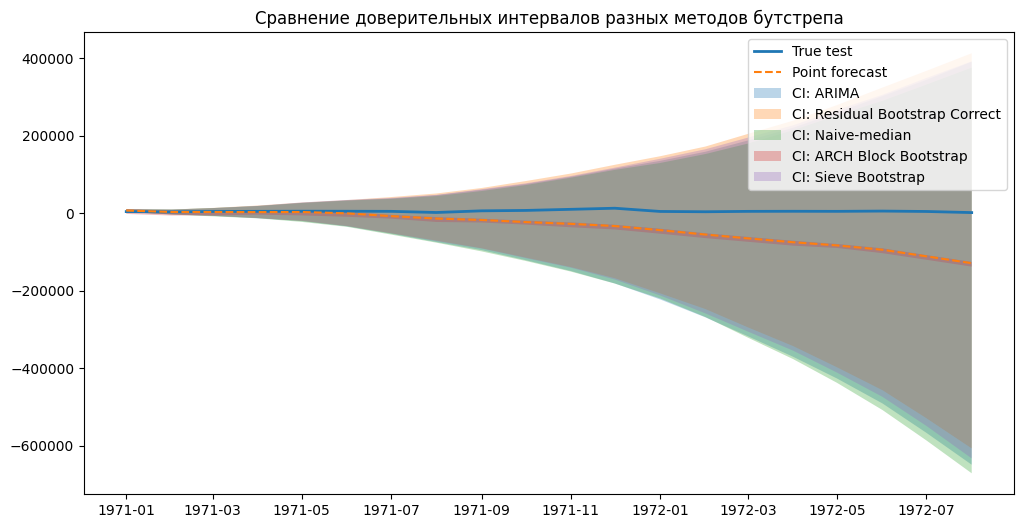

In [27]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['ARIMA', 'Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()

In [28]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 10.0, axis=0)
    upper = np.percentile(forecasts, 90.0, axis=0)
    
    return lower, upper, forecasts

# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = error_magnitude
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 10.0, axis=0)
    upper = np.percentile(forecasts, 90.0, axis=0)
    return lower, upper, forecasts

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast.values + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast.values + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 10.0, axis=0)
    upper = np.percentile(forecasts, 90.0, axis=0)

    return lower, upper, forecasts

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 10.0, axis=0)
    upper = np.percentile(forecasts, 90.0, axis=0)
    return lower, upper, forecasts

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 10.0, axis=0)
    upper = np.percentile(forecasts, 90.0, axis=0)
    return lower, upper, forecasts

def evaluate(true_values, lower, upper, alpha=0.2):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)

    # Winkler score
    penalty_factor = 2 / alpha
    lower_penalty = penalty_factor * np.maximum(0, lower - true_vals)
    upper_penalty = penalty_factor * np.maximum(0, true_vals - upper)
    width_penalty = (upper - lower)
    winkler_scores = width_penalty + lower_penalty + upper_penalty
    avg_winkler = np.mean(winkler_scores)

    return coverage, avg_width, avg_winkler

results = {}

# ARIMA
try:
    prediction = fitted_model.get_forecast(forecast_steps)
    arima_forecast = prediction.predicted_mean
    arima_ci = prediction.conf_int(alpha=0.2)
    lower_arima = arima_ci.iloc[:, 0]
    upper_arima = arima_ci.iloc[:, 1]
    coverage_arima, width_arima, winkler_arima = evaluate(test_values, lower_arima, upper_arima)
    results['ARIMA'] = {'coverage': coverage_arima, 'width': width_arima, 'lower': lower_arima, 'upper': upper_arima, "winkler": winkler_arima}
    print("ARIMA - OK")
except Exception as e:
    print(f"Arima error: {e}")

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c, winkler_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c, 'winkler': winkler_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive, winkler_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive, "winkler": winkler_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch, winkler_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch, 'winkler': winkler_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve, winkler_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve, 'winkler': winkler_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block, winkler_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block, 'winkler': winkler_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width', 'winkler']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

ARIMA - OK
Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[ 2833.00570729 -9214.38554115  4865.44043437  1784.07201532
  1727.54446266  -919.39621645  -554.54842541  1932.31554228
  1750.70102292  -423.57725663  -591.53708151 -1404.81003857
 -9107.95255275  1233.48333725  2557.14180884  3267.59661467
  3035.89557494  -141.49018198 -1518.98307981 -2530.29371737
  -162.90962697   501.13820019  1552.21865519  -883.22519849
 -4880.50048209  1915.87495335  2044.41120594   191.60054514
   725.40985725   946.62186891  2083.58232132   -25.48838813
  -843.75987388  -979.21423623  -793.77606723  -788.6766329
 -1417.04470349  -589.65224575   472.08630088  2102.83190076
  1115.10824894  1713.4633153   1905.93073092 -1958.6937489
   610.14629325 -1551.87194149  -235.93878002    96.5853331
 -6445.62262069  3184.69476764  2518.53711484   852.34415535
   984.33912542   117.13887858   672.74944711   860.35183039
   64